(120, 160) uint16


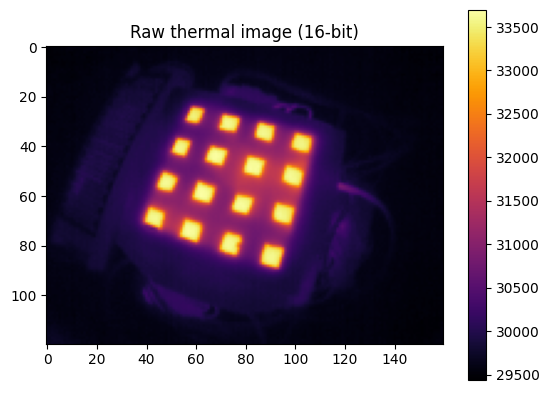

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

folder = "/home/aayushi/Documents/Lepton/capture_march_20"

img_path = sorted(glob.glob(folder + "/*.tiff"))[1]

img16 = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

print(img16.shape, img16.dtype)

plt.imshow(img16, cmap='inferno')
plt.colorbar()
plt.title("Raw thermal image (16-bit)")
plt.show()


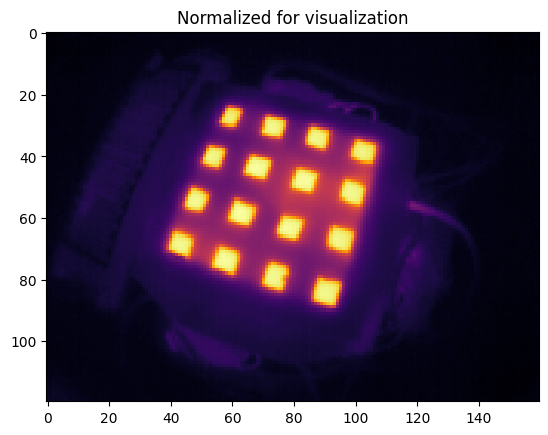

In [24]:
img8 = cv2.normalize(img16, None, 0, 255, cv2.NORM_MINMAX)
img8 = np.uint8(img8)

plt.imshow(img8, cmap='inferno')
plt.title("Normalized for visualization")
plt.show()


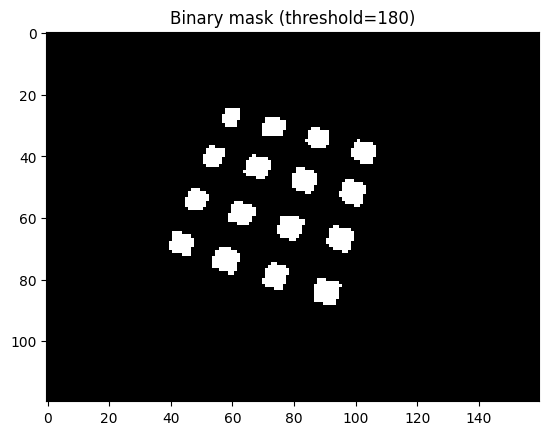

In [25]:
THRESH = 180   # <-- tune this

_, binary = cv2.threshold(img8, THRESH, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title(f"Binary mask (threshold={THRESH})")
plt.show()


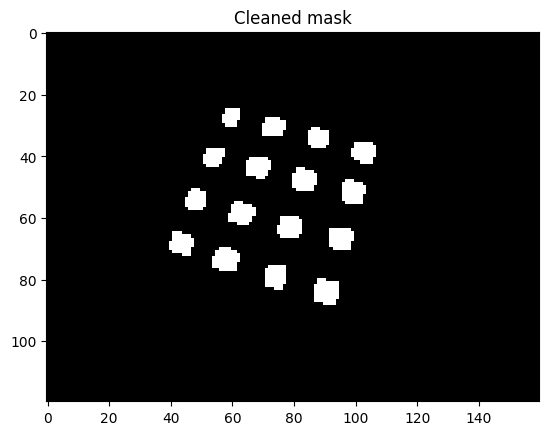

In [26]:
kernel = np.ones((3,3), np.uint8)

binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.imshow(binary, cmap='gray')
plt.title("Cleaned mask")
plt.show()


In [27]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)

# ignore background label 0
centroids = centroids[1:]
areas = stats[1:, cv2.CC_STAT_AREA]

print("Detected blobs:", len(centroids))


Detected blobs: 16


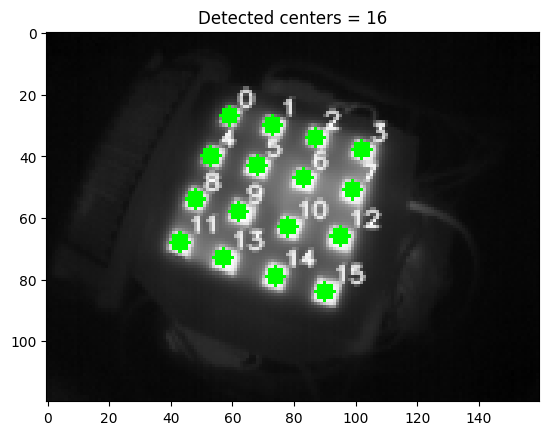

In [28]:
vis = cv2.cvtColor(img8, cv2.COLOR_GRAY2BGR)

for i,c in enumerate(centroids):
    x, y = int(c[0]), int(c[1])
    cv2.circle(vis, (x,y), 3, (0,255,0), -1)
    cv2.putText(
        vis,
        str(i),
        (x+3, y-3),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.25,
        (255,255,255),
        1,
        cv2.LINE_AA
    )

plt.imshow(vis)
plt.title(f"Detected centers = {len(centroids)}")
plt.show()


Total images: 38

Threshold performance:
Threshold 120 | perfect=1/38
Threshold 125 | perfect=1/38
Threshold 130 | perfect=1/38
Threshold 135 | perfect=1/38
Threshold 140 | perfect=2/38
Threshold 145 | perfect=3/38
Threshold 150 | perfect=3/38
Threshold 155 | perfect=3/38
Threshold 160 | perfect=4/38
Threshold 165 | perfect=4/38
Threshold 170 | perfect=5/38
Threshold 175 | perfect=6/38
Threshold 180 | perfect=8/38
Threshold 185 | perfect=24/38
Threshold 190 | perfect=38/38
Threshold 195 | perfect=38/38
Threshold 200 | perfect=38/38
Threshold 205 | perfect=38/38
Threshold 210 | perfect=38/38
Threshold 215 | perfect=38/38
Threshold 220 | perfect=37/38
Threshold 225 | perfect=35/38


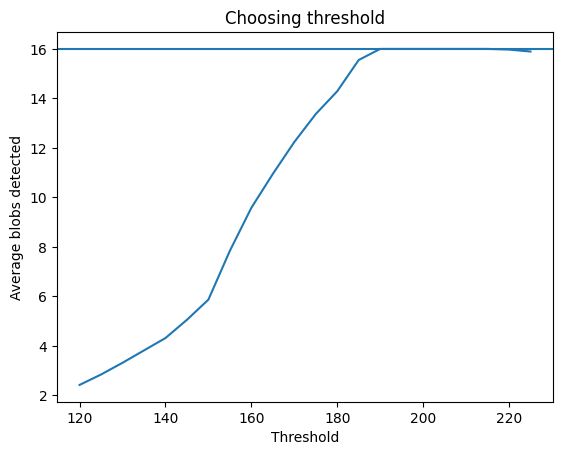

In [30]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

folder = "/home/aayushi/Documents/Lepton/capture_march_20"

image_paths = sorted(glob.glob(folder + "/*.tiff"))

print("Total images:", len(image_paths))

# thresholds to test
thresholds = range(120, 230, 5)

results = {}

kernel = np.ones((3,3), np.uint8)

for t in thresholds:

    counts = []

    for path in image_paths:

        img16 = cv2.imread(path, cv2.IMREAD_UNCHANGED)

        # normalize only for thresholding convenience
        img8 = cv2.normalize(img16, None, 0, 255, cv2.NORM_MINMAX)
        img8 = np.uint8(img8)

        _, binary = cv2.threshold(img8, t, 255, cv2.THRESH_BINARY)

        # clean noise
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        num_labels, _, _, _ = cv2.connectedComponentsWithStats(binary)

        counts.append(num_labels - 1)

    results[t] = counts


# print summary
print("\nThreshold performance:")
for t in thresholds:
    arr = np.array(results[t])

    print(
        f"Threshold {t:3d} | "
        f"perfect={(arr==16).sum()}/{len(arr)}"
    )


# plot how blob count changes with threshold
means = [np.mean(results[t]) for t in thresholds]

plt.figure()
plt.plot(list(thresholds), means)
plt.axhline(16)
plt.xlabel("Threshold")
plt.ylabel("Average blobs detected")
plt.title("Choosing threshold")
plt.show()


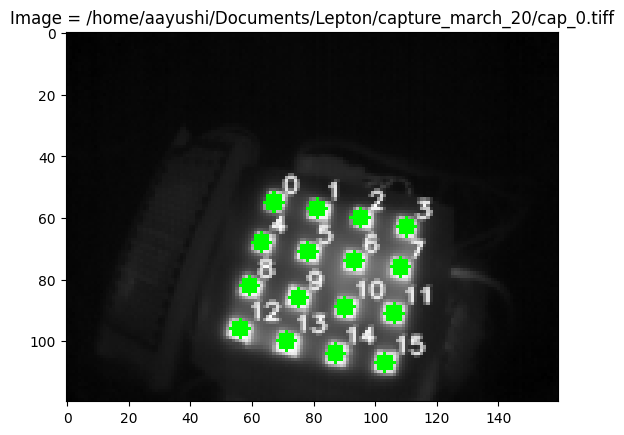

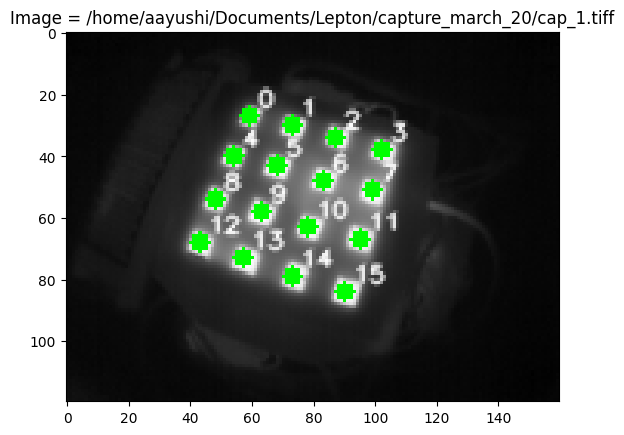

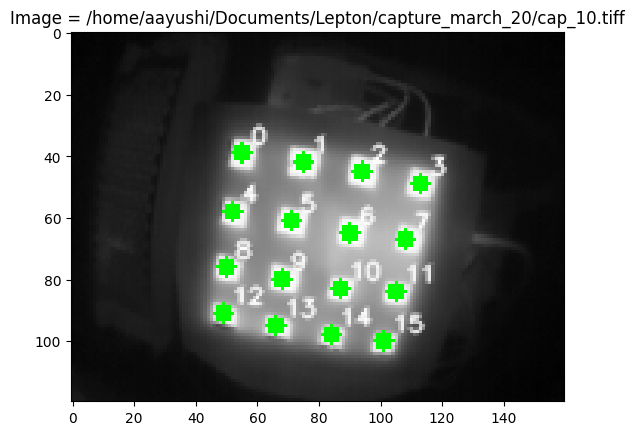

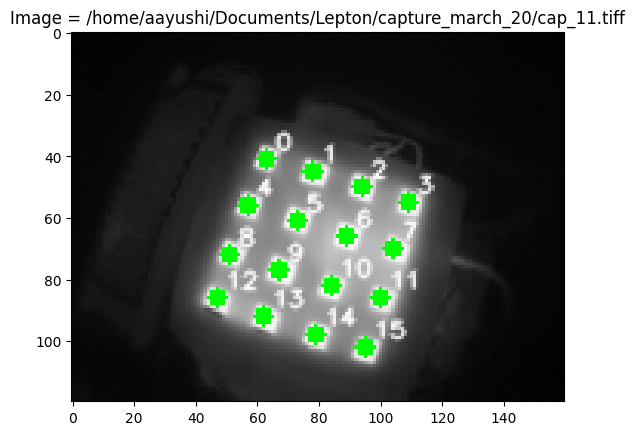

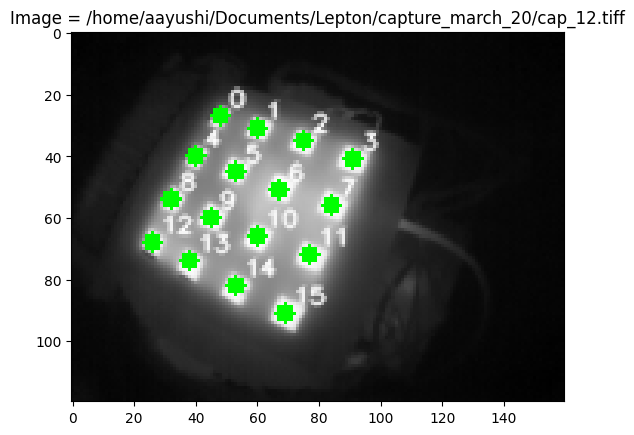

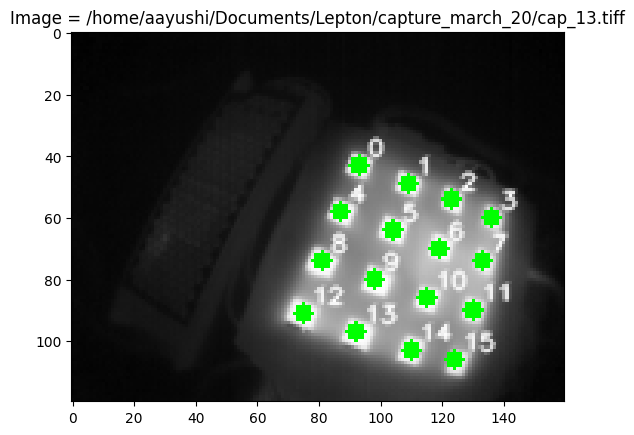

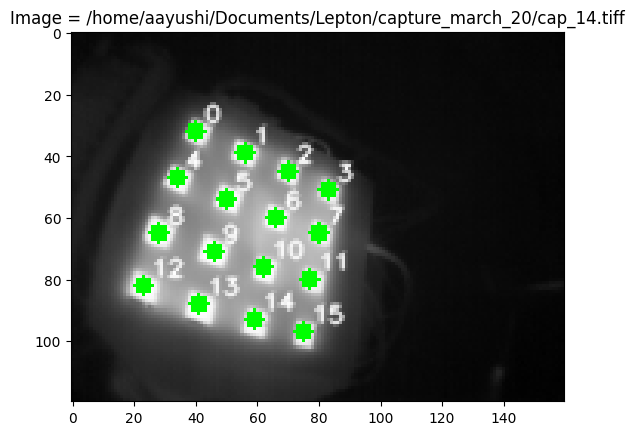

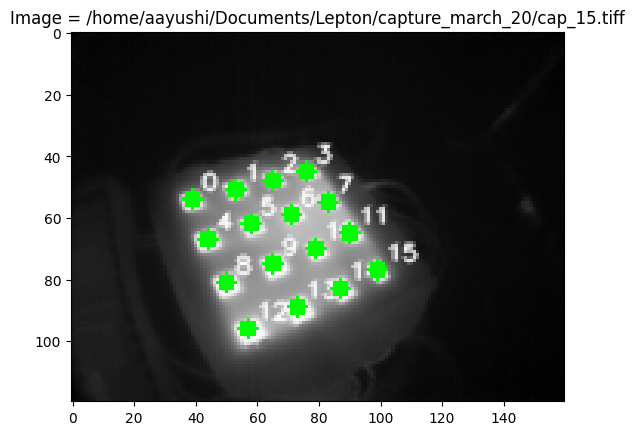

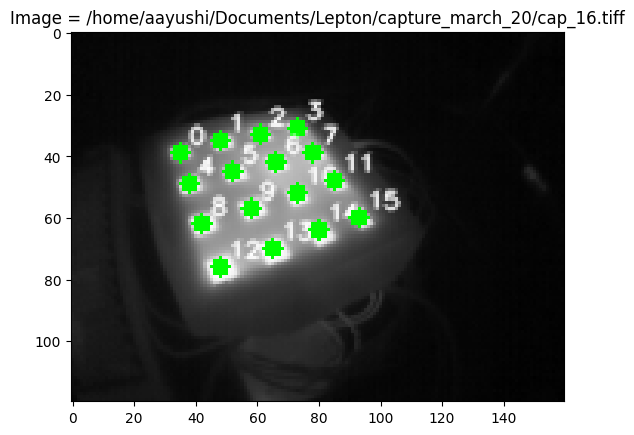

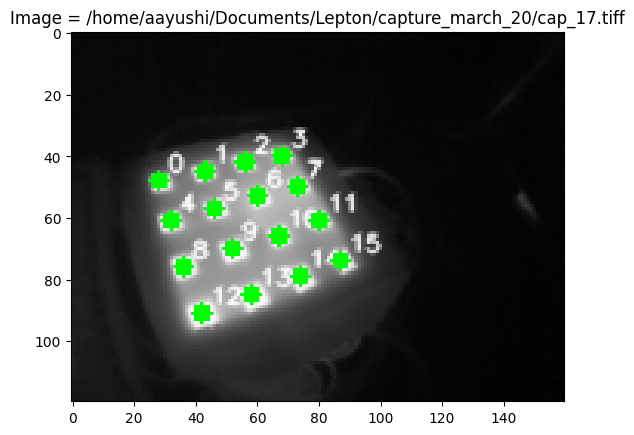

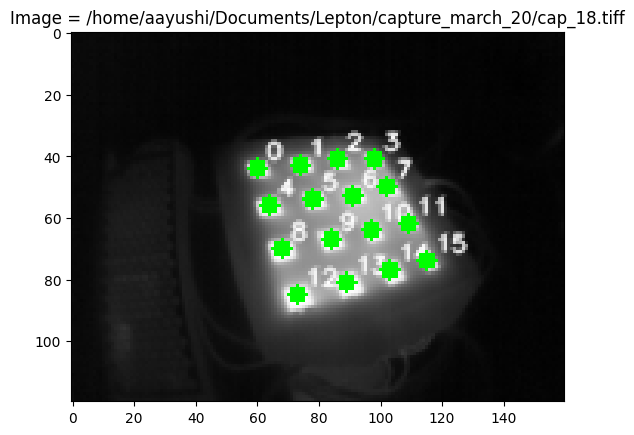

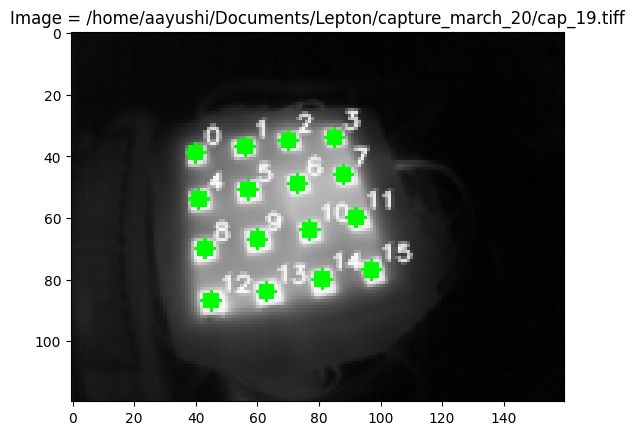

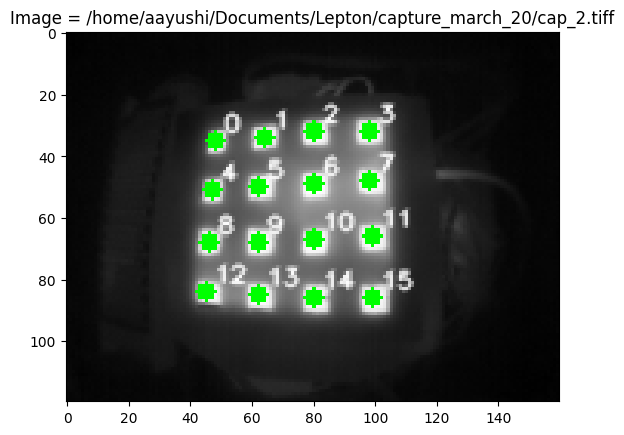

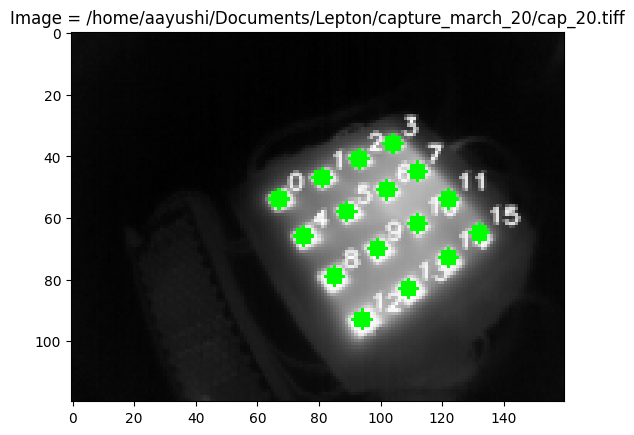

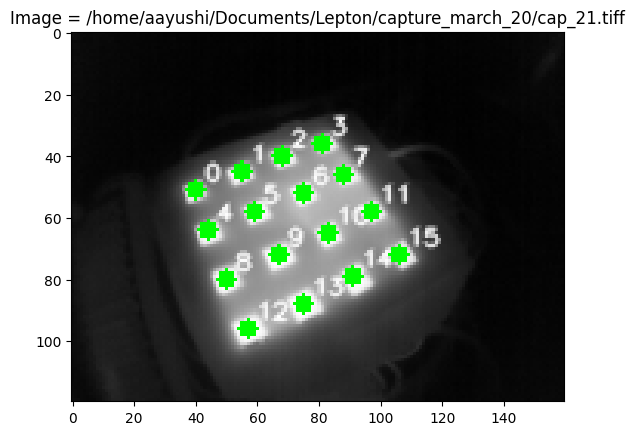

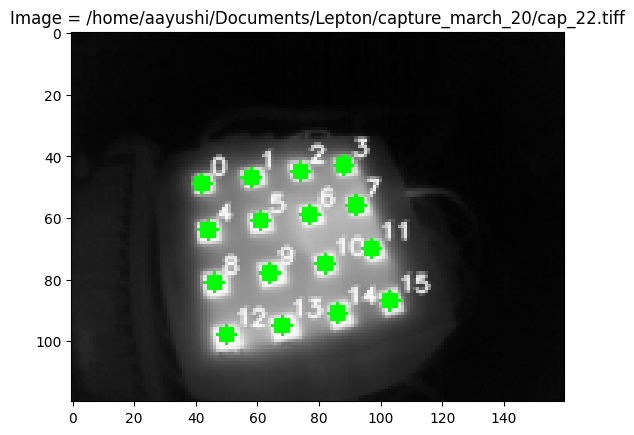

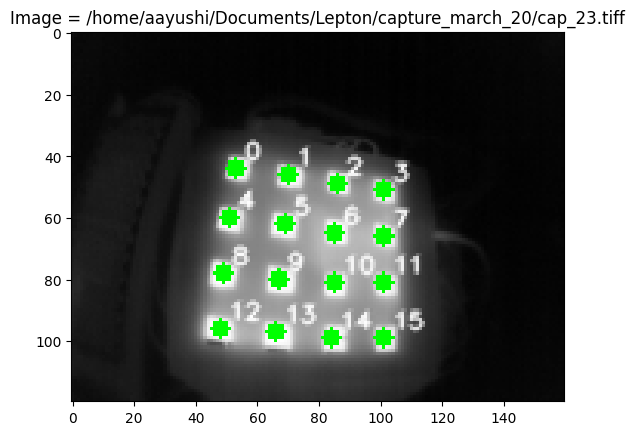

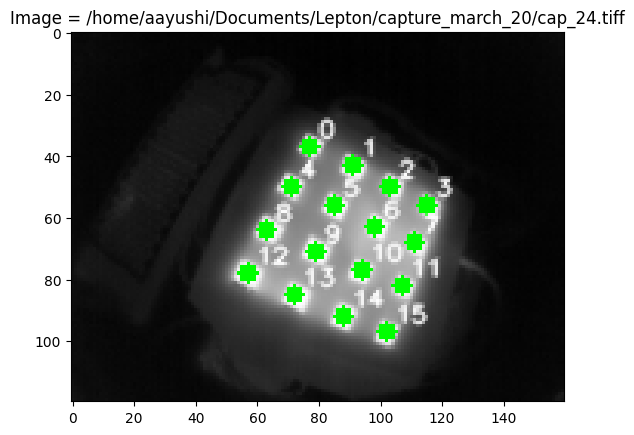

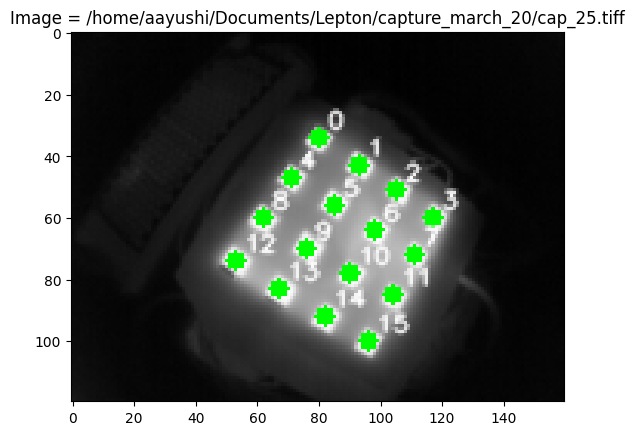

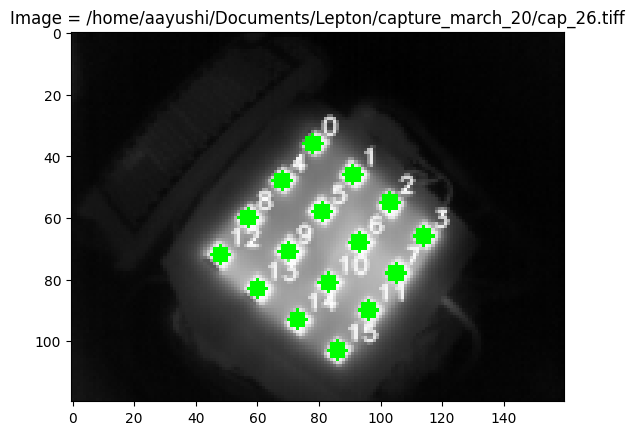

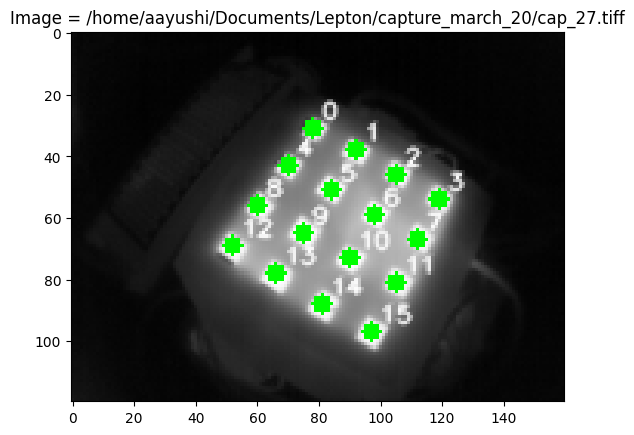

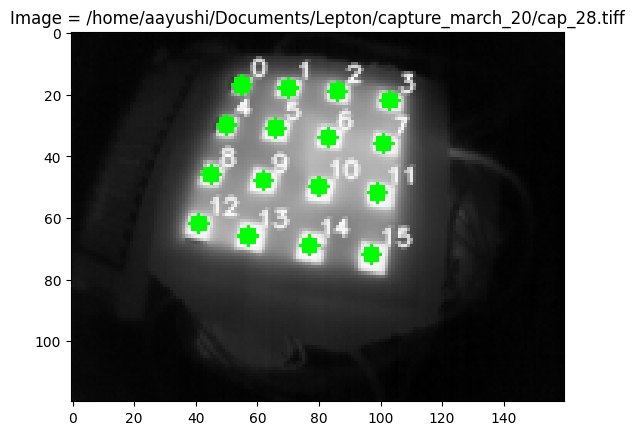

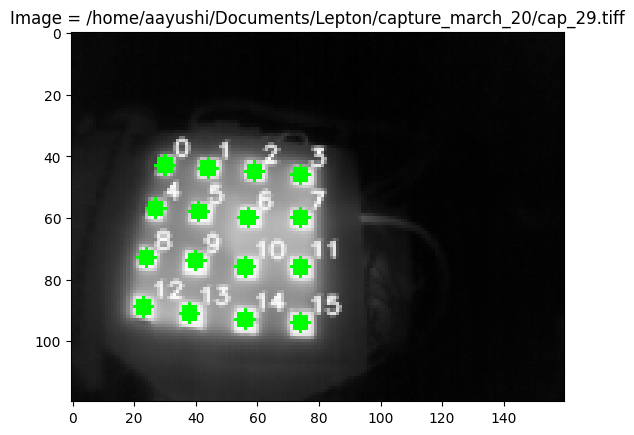

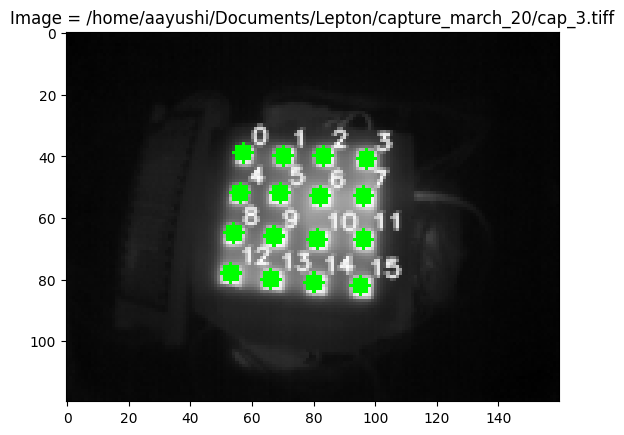

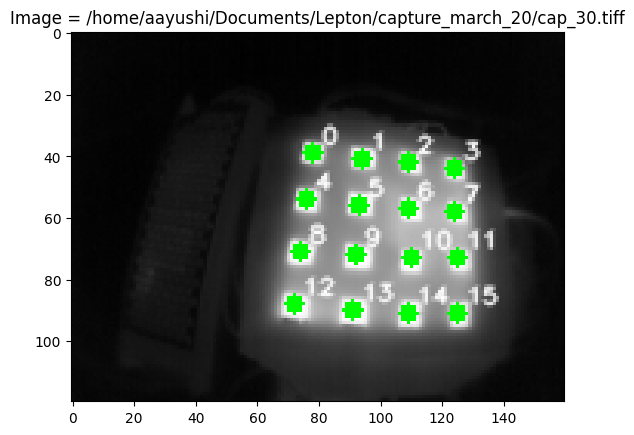

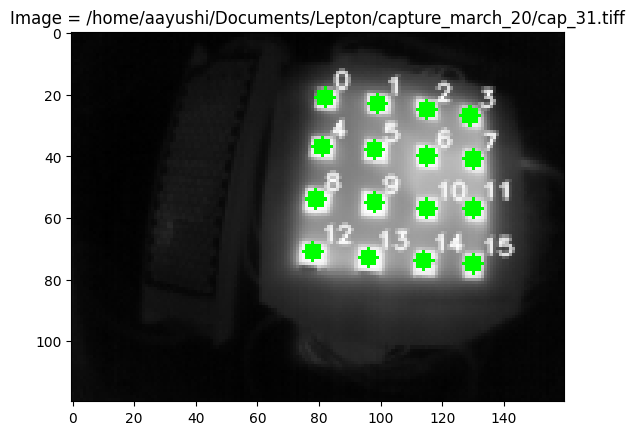

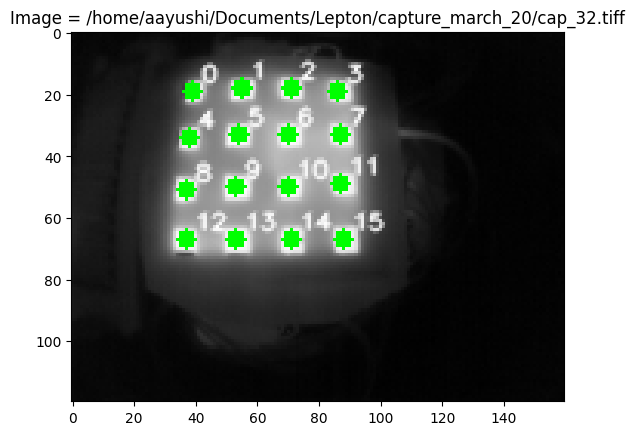

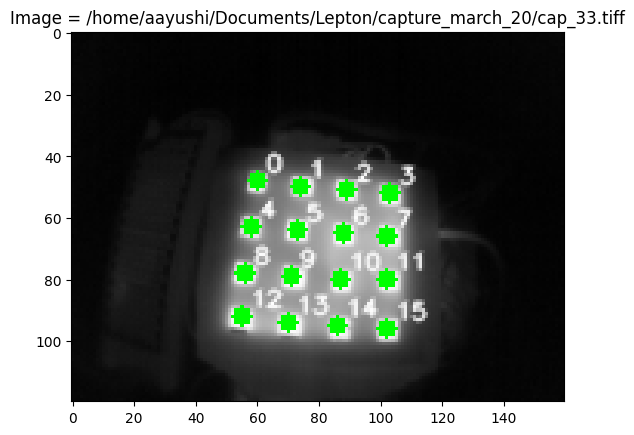

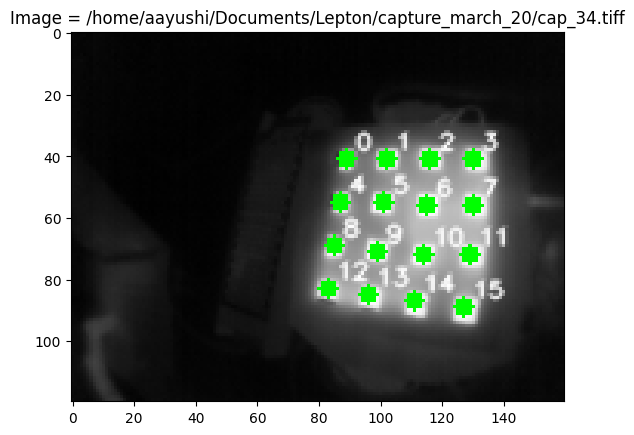

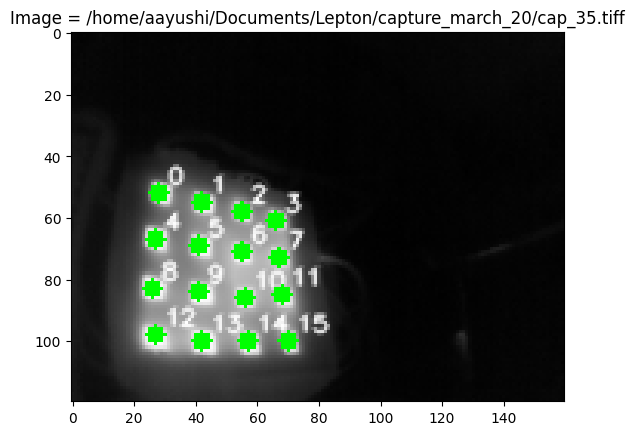

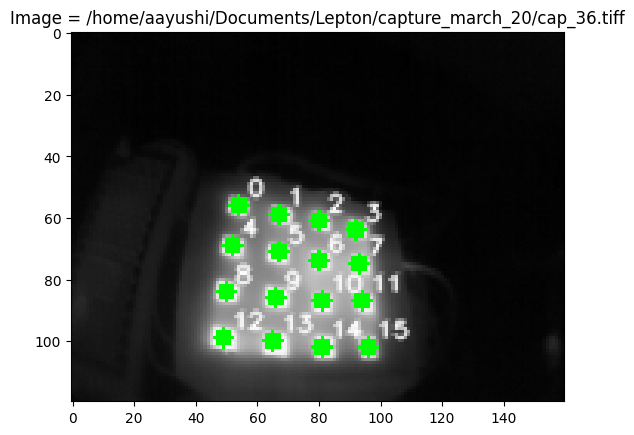

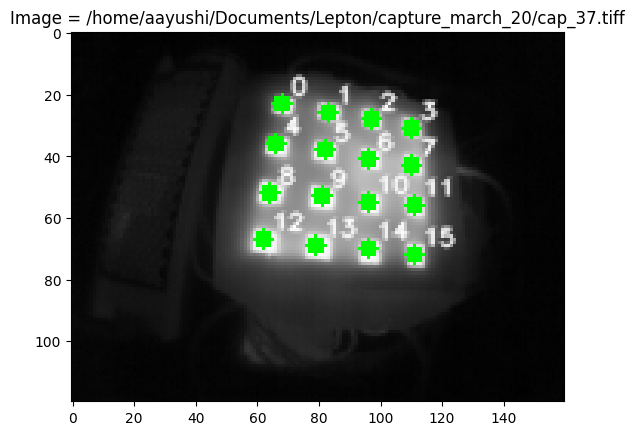

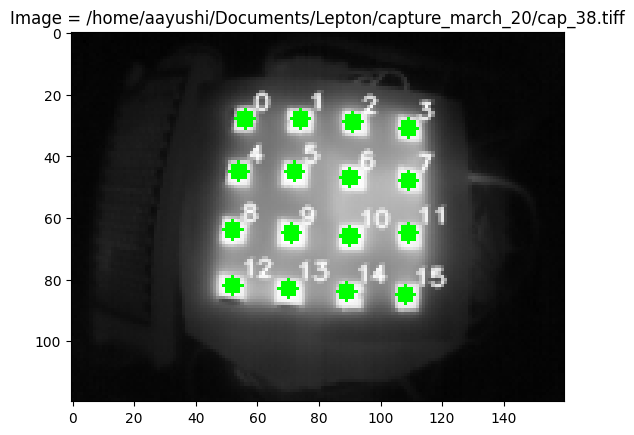

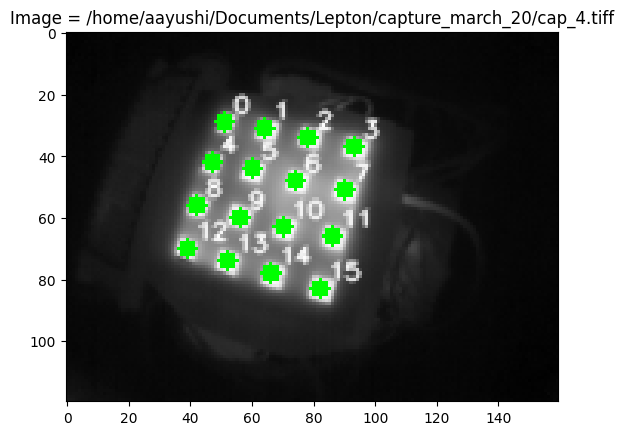

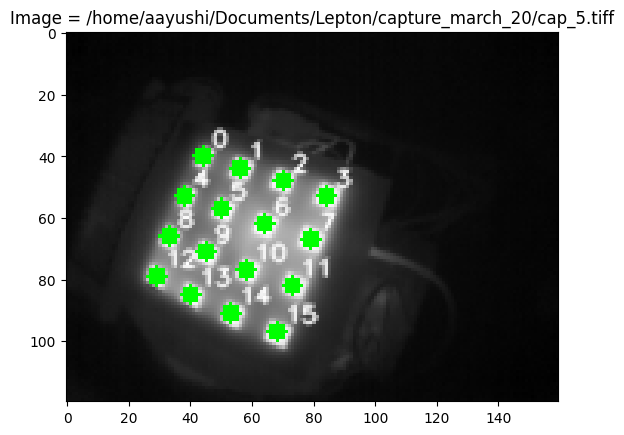

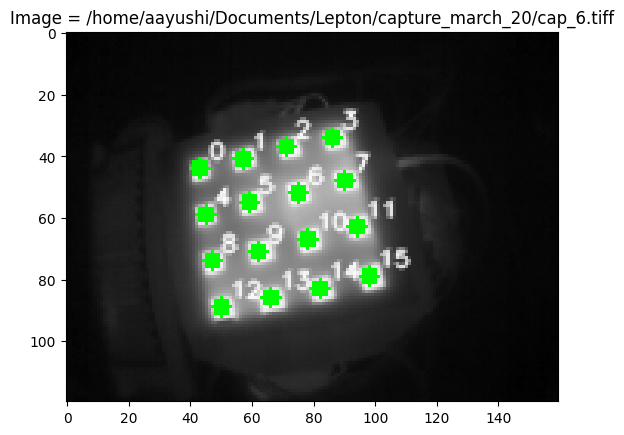

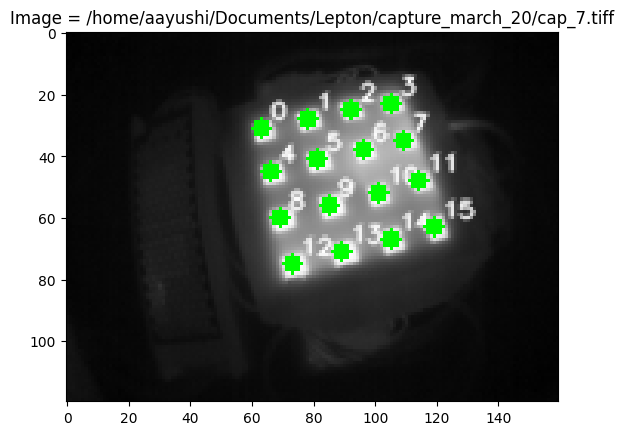

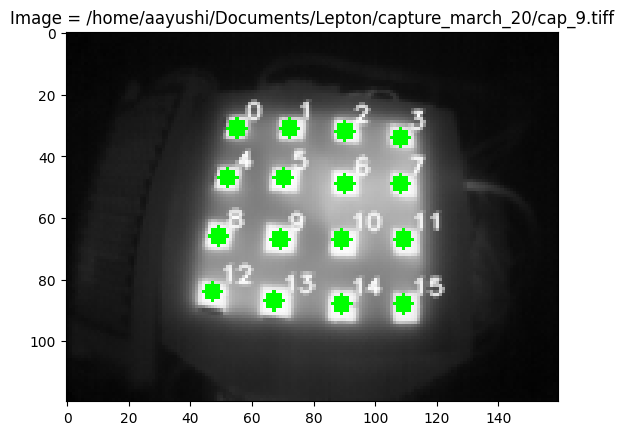

Images used: 38

Camera matrix:
 [[102.79120921   0.          88.1248276 ]
 [  0.         102.12965523  52.09958991]
 [  0.           0.           1.        ]]

Distortion:
 [[-3.34287078e-01  1.23327341e-01  2.59263123e-04 -3.61995700e-03
  -3.31170850e-02]]

Reprojection error: 0.3573964210626295


In [31]:
import cv2
import numpy as np
import glob
import os

folder = "/home/aayushi/Documents/Lepton/capture_march_20"
THRESH = 195     
rows, cols = 4, 4
spacing = 20/7      # mm

kernel = np.ones((3,3), np.uint8)

# 4x4 planar grid
objp = np.zeros((rows*cols, 3), np.float32)

objp[:, :2] = np.mgrid[
    0:cols,
    0:rows
].T.reshape(-1,2) * spacing

objpoints = []   # 3D points
imgpoints = []   # 2D points

def order_points_grid_diagonal(pts, rows=4, cols=4):

    pts = np.array(pts)

    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).flatten()

    TL = pts[np.argmin(s)]
    BR = pts[np.argmax(s)]

    TR = pts[np.argmin(diff)]
    BL = pts[np.argmax(diff)]

    vx = TR - TL
    vy = BL - TL

    vx = vx / np.linalg.norm(vx)
    vy = vy / np.linalg.norm(vy)

    coords = []

    for p in pts:

        v = p - TL

        x = np.dot(v, vx)
        y = np.dot(v, vy)

        coords.append([x,y])

    coords = np.array(coords)

    order = np.lexsort((coords[:,0], coords[:,1]))

    pts_sorted = pts[order]

    ordered = []

    for r in range(rows):
        row_pts = pts_sorted[r*cols:(r+1)*cols]
        row_pts = row_pts[np.argsort(row_pts[:,0])]
        ordered.append(row_pts)

    return np.vstack(ordered)


image_paths = sorted(glob.glob(folder + "/*.tiff"))

for idx,path in enumerate(image_paths):

    img16 = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    # normalize for thresholding
    img8 = cv2.normalize(img16, None, 0, 255, cv2.NORM_MINMAX)
    img8 = np.uint8(img8)

    _, binary = cv2.threshold(img8, THRESH, 255, cv2.THRESH_BINARY)

    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)

    if num_labels-1 != 16:
        print("Skipping:", path)
        continue

    pts = centroids[1:]   # remove background
    vis = cv2.cvtColor(img8, cv2.COLOR_GRAY2BGR)
    pts=order_points_grid_diagonal(pts)
    for i,c in enumerate(pts):
        x, y = int(c[0]), int(c[1])
        cv2.circle(vis, (x,y), 3, (0,255,0), -1)
        cv2.putText(
            vis,
            str(i),
            (x+3, y-3),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.25,
            (255,255,255),
            1,
            cv2.LINE_AA
        )

    plt.imshow(vis)
    plt.title(f"Image = {image_paths[idx]}")
    plt.show()
    

    objpoints.append(objp)
    imgpoints.append(pts.astype(np.float32))


print("Images used:", len(objpoints))

h, w = img16.shape

ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    (w, h),
    None,
    None
)

print("\nCamera matrix:\n", K)
print("\nDistortion:\n", dist)
print("\nReprojection error:", ret)
